# GridWorld Variant B — Uncertainty-Guided Action Only

50×50 grid. Identical to Variant B except the **only** AL difference is action selection during exploration.
No committee, no QBC start state — isolating the effect of uncertainty-guided action selection alone.

| | Baseline (Standard) | AL (uncertainty action only) |
|---|---|---|
| **Episode start state** | Uniformly random non-wall cell | Uniformly random non-wall cell (same as baseline) |
| **Action selection (exploration)** | Uniform random | Biased toward highest-uncertainty neighbour (Q-std + visit bonus) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded.')

Libraries loaded.


## 1. GridWorld Environment

In [2]:
class GridWorldEnv:
    """
    Base GridWorld: rows = battery level, cols = transformer load.
    Actions: up (battery+1), down (battery-1), right (load+1), left (load-1).
    Reward: +500 goal (terminal), -10 wall (terminal), -1 per step.
    """

    def __init__(self, grid_size=10):
        self.grid_size = grid_size
        self.n_actions = 4
        self.action_names = ['up', 'down', 'right', 'left']
        self.walls = self._build_walls()
        self.goal  = self._build_goal()
        self.state = None
        self.reset()

    def _build_walls(self):
        walls = np.zeros((self.grid_size, self.grid_size), dtype=bool)
        walls[:, 9] = True
        return walls

    def _build_goal(self):
        goal = np.zeros((self.grid_size, self.grid_size), dtype=bool)
        for b in range(4, 9):
            for l in range(0, 7):
                goal[b, l] = True
        return goal

    def reset(self, start_state=None):
        if start_state is not None:
            self.state = start_state
        else:
            while True:
                b = np.random.randint(self.grid_size)
                l = np.random.randint(self.grid_size)
                if not self.walls[b, l]:
                    self.state = (b, l)
                    break
        return self.state

    def step(self, action):
        b, l = self.state
        if action == 0:    # up: battery +1
            b = min(b + 1, self.grid_size - 1)
        elif action == 1:  # down: battery -1
            b = max(b - 1, 0)
        elif action == 2:  # right: load +1
            l = min(l + 1, self.grid_size - 1)
        elif action == 3:  # left: load -1
            l = max(l - 1, 0)
        next_state = (b, l)
        if self.walls[b, l]:
            reward, done = -10, True
        elif self.goal[b, l]:
            reward, done = +500, True
        else:
            reward, done = -1, False
        self.state = next_state
        return next_state, reward, done


print('GridWorldEnv defined.')

GridWorldEnv defined.


## 2. Q-Learning Agent (with uncertainty-guided action)

A single Q-table agent. When `use_al=True` and the agent is exploring (prob ε),
it calls `_al_action` instead of picking uniformly at random.

`_al_action` scores each candidate action by the uncertainty of the state it would land in:
- **Q-std**: std of Q-values across actions at that cell — low std means the agent has no clear preference yet
- **visit bonus**: `1 / (1 + visit_count)` — penalises already-visited cells

Actions are sampled in proportion to these scores, so the agent naturally drifts toward
under-explored, uncertain regions of the grid.

In [3]:
class QLearningAgent:

    def __init__(self, grid_size=10, n_actions=4, action_deltas=None,
                 alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.grid_size     = grid_size
        self.n_actions     = n_actions
        self.action_deltas = action_deltas or [(+1,0),(-1,0),(0,+1),(0,-1)]
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self._init_tables()

    def _init_tables(self):
        self.Q           = np.zeros((self.grid_size, self.grid_size, self.n_actions))
        self.visit_count = np.zeros((self.grid_size, self.grid_size))

    def get_uncertainty_map(self):
        """Per-cell uncertainty: Q-std across actions + unvisited-cell bonus."""
        q_std       = np.std(self.Q, axis=2)
        visit_bonus = 1.0 / (1.0 + self.visit_count)
        return q_std + 0.5 * visit_bonus

    def _al_action(self, state):
        """During exploration, prefer the action leading to the highest-uncertainty neighbour."""
        uncertainty = self.get_uncertainty_map()
        b, l = state
        gs = self.grid_size
        next_states = [
            (int(np.clip(b + db, 0, gs - 1)), int(np.clip(l + dl, 0, gs - 1)))
            for db, dl in self.action_deltas
        ]
        scores = np.array([uncertainty[ns] for ns in next_states]) + 1e-8
        probs  = scores / scores.sum()
        return int(np.random.choice(self.n_actions, p=probs))

    def select_action(self, state, use_al=False):
        if np.random.random() < self.epsilon:
            return self._al_action(state) if use_al else np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state[0], state[1]]))

    def update(self, state, action, reward, next_state, done):
        b, l   = state
        nb, nl = next_state
        target = reward if done else reward + self.gamma * np.max(self.Q[nb, nl])
        self.Q[b, l, action] += self.alpha * (target - self.Q[b, l, action])
        self.visit_count[b, l] += 1

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_policy(self):
        return np.argmax(self.Q, axis=2)

    def reset_all(self):
        self.epsilon = 1.0
        self._init_tables()


print('QLearningAgent defined.')

QLearningAgent defined.


## 3. Visualization Helpers

In [4]:
ARROW_DIR = {
    0: ( 0,   +0.35),  # up         (battery+1, load=0) — solar power
    1: ( 0,   -0.35),  # down       (battery-1, load=0) — car drain
    2: (+0.35, 0   ),  # right      (battery=0, load+1) — transformer busy
    3: (-0.35, 0   ),  # left       (battery=0, load-1) — transformer idle
    4: (+0.25,+0.25),  # up-right   (battery+1, load+1) — transformer charges car
}
ACTION_COLOR = {0: 'goldenrod', 1: 'gray', 2: 'darkorange', 3: 'steelblue', 4: 'navy'}


def _style_grid_ax(ax, title, grid_size=10, step_pct=10):
    ax.set_xlabel('Transformer Load', fontsize=10)
    ax.set_ylabel('Battery Level', fontsize=10)
    ticks = range(0, grid_size, max(1, grid_size // 10))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{i*step_pct}%' for i in ticks], fontsize=7)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{i*step_pct}%' for i in ticks], fontsize=7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, color='gray', alpha=0.2, linewidth=0.3)


def smooth(arr, w=25):
    return np.convolve(arr, np.ones(w) / w, mode='valid')


print('Visualization helpers defined.')

Visualization helpers defined.


## 4. Training Function

In [5]:
def train_with_budget_b(env, agent, n_episodes=1500, max_steps=500, use_al=False,
                        eval_env=None, eval_step_interval=1000, eval_episodes=50):
    """
    Train agent for n_episodes, tracking per-episode rewards and step counts.

    Start-state logic:
      always random non-wall start for both baseline and AL.

    Action selection during exploration:
      use_al=False  -> uniform random
      use_al=True   -> uncertainty-guided (_al_action: Q-std + visit bonus)

    If eval_env is given, freezes epsilon=0 every eval_step_interval cumulative
    environment steps and runs eval_episodes greedy rollouts from random starts.
    Returns eval_log as a list of (cumulative_steps, mean_eval_reward) tuples.
    """
    rewards, step_counts, eval_log = [], [], []
    total_steps  = 0
    next_eval_at = eval_step_interval

    for ep in range(n_episodes):
        state = env.reset()  # always random start
        ep_reward, ep_steps = 0, 0

        for _ in range(max_steps):
            action              = agent.select_action(state, use_al=use_al)
            next_state, r, done = env.step(action)
            agent.update(state, action, r, next_state, done)
            state       = next_state
            ep_reward  += r
            ep_steps   += 1
            total_steps += 1

            # Trigger greedy eval at every eval_step_interval boundary
            while eval_env is not None and total_steps >= next_eval_at:
                saved_eps = agent.epsilon
                agent.epsilon = 0.0
                ep_evals = []
                for _ in range(eval_episodes):
                    s = eval_env.reset()
                    er = 0
                    for _ in range(max_steps):
                        a         = agent.select_action(s, use_al=False)
                        ns, rv, d = eval_env.step(a)
                        s  = ns
                        er += rv
                        if d:
                            break
                    ep_evals.append(er)
                agent.epsilon = saved_eps
                eval_log.append((next_eval_at, float(np.mean(ep_evals))))
                next_eval_at += eval_step_interval

            if done:
                break

        agent.decay_epsilon()
        rewards.append(ep_reward)
        step_counts.append(ep_steps)

    return rewards, step_counts, eval_log


print('train_with_budget_b() defined.')

train_with_budget_b() defined.


## 5. GridWorld Variant B Environment

Same as Variant B: 50×50 grid, wall zone load > 90% or battery < 5%, goal battery 70–80% load 30–60%.

Five actions with per-step rewards:
| Action | Movement | Step reward |
|---|---|---|
| ↑ Up | battery+1 | −1 |
| ↓ Down | battery−1 | −1 |
| → Right | load+1 | −1 |
| ← Left | load−1 | −1 |
| ↗ Up-right | battery+1, load+1 | 0 |

Variant B  —  grid 50×50, non-wall: 2115, goal: 96, goal fraction: 4.5%


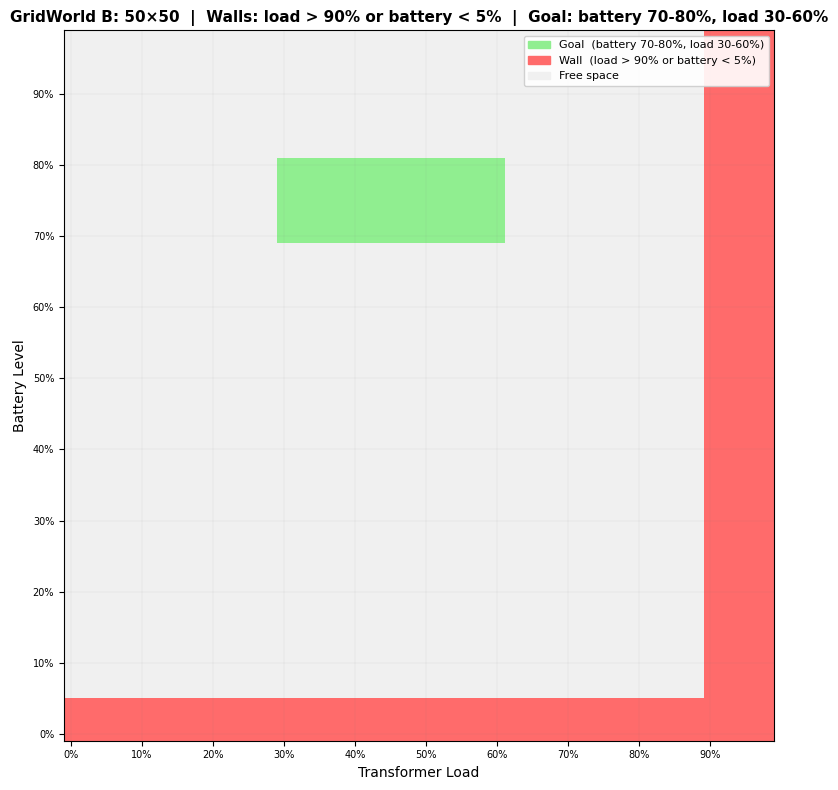

In [6]:
class GridWorldEnvB(GridWorldEnv):
    """50×50 grid.
    Walls: load > 90% OR battery < 5%.
    Goal:  battery 70-80% AND load 30-60%.
    Actions: up, down, right, left, up-right (transformer charges car, step 0).
    """

    DELTAS = [(+1,0),(-1,0),(0,+1),(0,-1),(+1,+1)]  # up, down, right, left, up-right

    def __init__(self):
        super().__init__(grid_size=50)
        self.n_actions    = 5
        self.action_names = ['up', 'down', 'right', 'left', 'up-right']

    def _build_walls(self):
        walls = np.zeros((50, 50), dtype=bool)
        walls[:, 45:] = True   # load > 90%
        walls[:3, :]  = True   # battery < 5% (rows 0,1,2 → 0%,2%,4%)
        return walls

    def _build_goal(self):
        goal = np.zeros((50, 50), dtype=bool)
        for b in range(35, 41):     # battery 70-80%
            for l in range(15, 31): # load 30-60%
                goal[b, l] = True
        goal[self.walls] = False
        return goal

    def step(self, action):
        b, l = self.state
        db, dl = self.DELTAS[action]
        b = int(np.clip(b + db, 0, self.grid_size - 1))
        l = int(np.clip(l + dl, 0, self.grid_size - 1))
        next_state = (b, l)
        if self.walls[b, l]:
            reward, done = -3000, True
        elif self.goal[b, l]:
            reward, done = +5000, True
        else:
            reward = 0 if action == 4 else -1
            done   = False
        self.state = next_state
        return next_state, reward, done


env_b = GridWorldEnvB()
nw = (~env_b.walls).sum()
ng = env_b.goal.sum()
print(f'Variant B  —  grid 50×50, non-wall: {nw}, goal: {ng}, goal fraction: {ng/nw:.1%}')

display = np.zeros((50, 50))
display[env_b.goal]  = 1
display[env_b.walls] = 2
cmap = ListedColormap(['#f0f0f0', '#90ee90', '#ff6b6b'])
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(display, cmap=cmap, origin='lower', aspect='equal',
          extent=[-0.5, 49.5, -0.5, 49.5])
ticks = range(0, 50, 5)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{i*2}%' for i in ticks], fontsize=7)
ax.set_yticks(ticks)
ax.set_yticklabels([f'{i*2}%' for i in ticks], fontsize=7)
ax.set_xlabel('Transformer Load', fontsize=10)
ax.set_ylabel('Battery Level',    fontsize=10)
ax.set_title('GridWorld B: 50×50  |  Walls: load > 90% or battery < 5%  |  Goal: battery 70-80%, load 30-60%',
             fontsize=11, fontweight='bold')
ax.grid(True, color='gray', alpha=0.2, linewidth=0.3)
patches_legend = [
    mpatches.Patch(color='#90ee90', label='Goal  (battery 70-80%, load 30-60%)'),
    mpatches.Patch(color='#ff6b6b', label='Wall  (load > 90% or battery < 5%)'),
    mpatches.Patch(color='#f0f0f0', label='Free space'),
]
ax.legend(handles=patches_legend, loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

## 6. Training: Baseline (uniform random) vs AL (uncertainty-guided action)

- **Baseline**: `QLearningAgent` — random start state, uniform random exploration
- **AL (uncertainty action only)**: `QLearningAgent` — random start state, uncertainty-guided exploration (no committee, no QBC start state)

In [7]:
N_SEEDS_B          = 5
N_EP_B             = 3500
EVAL_STEP_INTERVAL = 1000   # greedy eval every N cumulative environment steps

a_std_r, a_std_s, a_std_eval = [], [], []
a_al_r,  a_al_s,  a_al_eval  = [], [], []
plot_agent_std_b = plot_agent_al_b = plot_env_b = None

for seed in range(N_SEEDS_B):
    np.random.seed(seed)

    # Baseline: uniform random exploration
    e_s = GridWorldEnvB()
    a_s = QLearningAgent(grid_size=50, n_actions=5, action_deltas=GridWorldEnvB.DELTAS,
                         epsilon_decay=0.998)
    r_s, st_s, ev_s = train_with_budget_b(
        e_s, a_s, n_episodes=N_EP_B, max_steps=500, use_al=False,
        eval_env=GridWorldEnvB(), eval_step_interval=EVAL_STEP_INTERVAL, eval_episodes=50)
    a_std_r.append(r_s)
    a_std_s.append(np.cumsum(st_s))
    a_std_eval.append(ev_s)

    # AL: uncertainty-guided exploration (same agent class, use_al=True)
    e_a = GridWorldEnvB()
    a_a = QLearningAgent(grid_size=50, n_actions=5, action_deltas=GridWorldEnvB.DELTAS,
                         epsilon_decay=0.998)
    r_a, st_a, ev_a = train_with_budget_b(
        e_a, a_a, n_episodes=N_EP_B, max_steps=500, use_al=True,
        eval_env=GridWorldEnvB(), eval_step_interval=EVAL_STEP_INTERVAL, eval_episodes=50)
    a_al_r.append(r_a)
    a_al_s.append(np.cumsum(st_a))
    a_al_eval.append(ev_a)

    if seed == 0:
        plot_agent_std_b = a_s
        plot_agent_al_b  = a_a
        plot_env_b       = GridWorldEnvB()

print('Variant B training done.')
print(f'  Standard  final 50-ep avg: {np.array(a_std_r)[:, -50:].mean():.1f}')
print(f'  AL-Guided final 50-ep avg: {np.array(a_al_r)[:, -50:].mean():.1f}')

Variant B training done.
  Standard  final 50-ep avg: 4955.4
  AL-Guided final 50-ep avg: 4986.4


## 7. Learned Policy Comparison (seed 0)

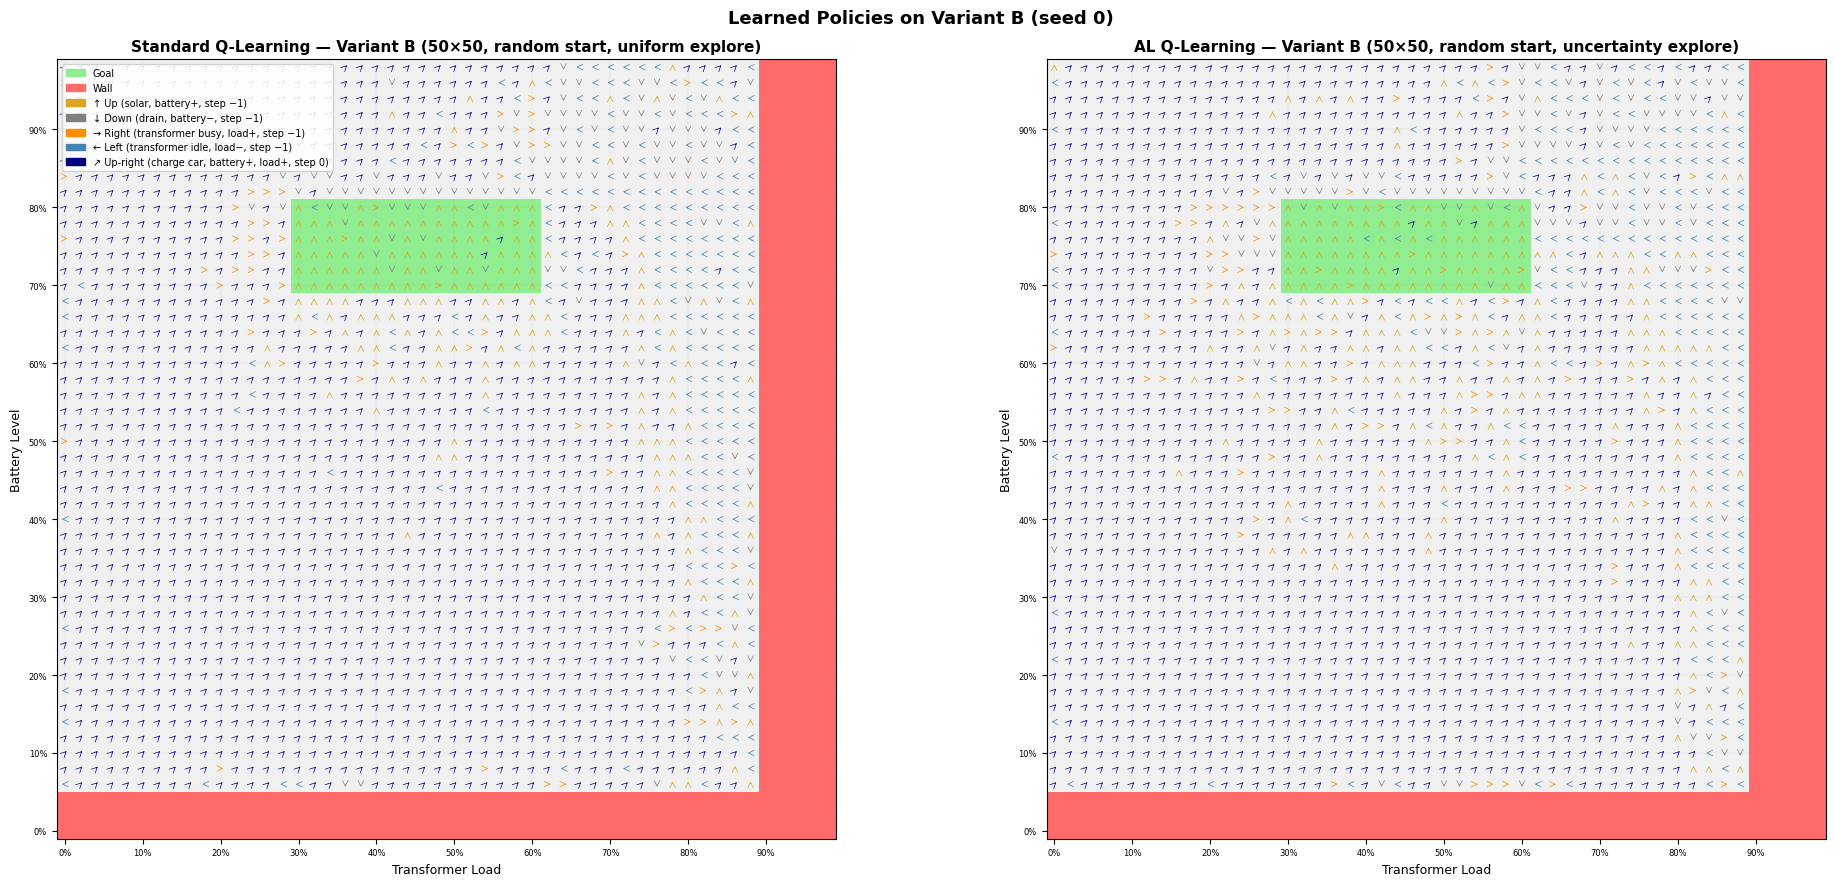

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, agent, label in [
    (axes[0], plot_agent_std_b, 'Standard Q-Learning — Variant B (50×50, random start, uniform explore)'),
    (axes[1], plot_agent_al_b,  'AL Q-Learning — Variant B (50×50, random start, uncertainty explore)'),
]:
    display = np.zeros((50, 50))
    display[plot_env_b.goal]  = 1
    display[plot_env_b.walls] = 2
    cmap = ListedColormap(['#f0f0f0', '#90ee90', '#ff6b6b'])
    ax.imshow(display, cmap=cmap, origin='lower', aspect='equal',
              extent=[-0.5, 49.5, -0.5, 49.5])

    policy = agent.get_policy()
    for b in range(50):
        for l in range(50):
            if plot_env_b.walls[b, l]:
                continue
            a = policy[b, l]
            dx, dy = ARROW_DIR[a]
            ax.annotate('', xy=(l + dx, b + dy),
                        xytext=(l - dx * 0.4, b - dy * 0.4),
                        arrowprops=dict(arrowstyle='->', color=ACTION_COLOR[a], lw=0.5))
    ticks = range(0, 50, 5)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{i*2}%' for i in ticks], fontsize=6)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{i*2}%' for i in ticks], fontsize=6)
    ax.set_xlabel('Transformer Load', fontsize=9)
    ax.set_ylabel('Battery Level',   fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, color='gray', alpha=0.15, linewidth=0.3)

patches_leg = [
    mpatches.Patch(color='#90ee90',    label='Goal'),
    mpatches.Patch(color='#ff6b6b',    label='Wall'),
    mpatches.Patch(color='goldenrod',  label='↑ Up (solar, battery+, step −1)'),
    mpatches.Patch(color='gray',       label='↓ Down (drain, battery−, step −1)'),
    mpatches.Patch(color='darkorange', label='→ Right (transformer busy, load+, step −1)'),
    mpatches.Patch(color='steelblue',  label='← Left (transformer idle, load−, step −1)'),
    mpatches.Patch(color='navy',       label='↗ Up-right (charge car, battery+, load+, step 0)'),
]
axes[0].legend(handles=patches_leg, loc='upper left', fontsize=7, framealpha=0.9)
plt.suptitle('Learned Policies on Variant B (seed 0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Budget Comparison: Reward vs Environment Steps

Final performance  — standard: 4955.4,  AL: 4986.4
Convergence threshold (90% of lower): 4459


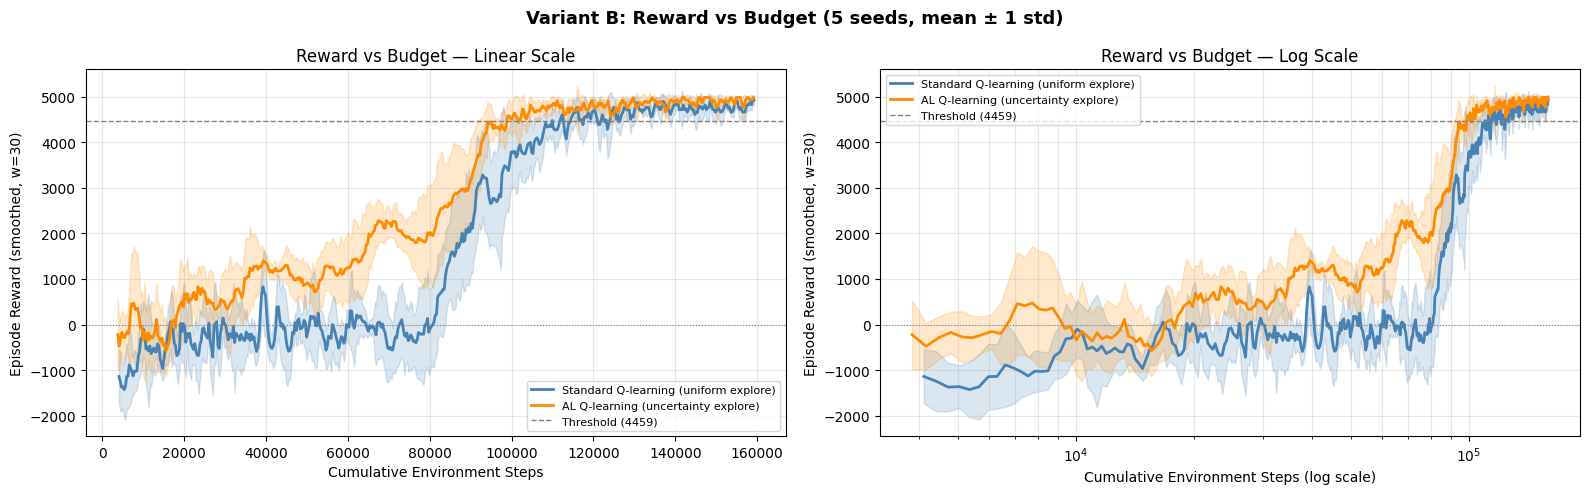

In [9]:
W_B = 30

final_std_b = np.array(a_std_r)[:, -50:].mean()
final_al_b  = np.array(a_al_r)[:, -50:].mean()
THRESHOLD_B = int(0.90 * min(final_std_b, final_al_b))
print(f'Final performance  — standard: {final_std_b:.1f},  AL: {final_al_b:.1f}')
print(f'Convergence threshold (90% of lower): {THRESHOLD_B}')


def budget_curves_b(rl, sl, w=W_B):
    x_min = max(cs[w - 1] for cs in sl)
    x_max = min(cs[-1]    for cs in sl)
    x_grid = np.linspace(x_min, x_max, 500)
    curves = []
    for rewards, cum_steps in zip(rl, sl):
        smoothed = smooth(rewards, w)
        x_pts    = cum_steps[w - 1:]
        curves.append(np.interp(x_grid, x_pts, smoothed))
    return x_grid, np.array(curves)


x_std_b, mat_std_b = budget_curves_b(a_std_r, a_std_s)
x_al_b,  mat_al_b  = budget_curves_b(a_al_r,  a_al_s)

x_lo  = max(x_std_b[0],  x_al_b[0])
x_hi  = min(x_std_b[-1], x_al_b[-1])
m_std = (x_std_b >= x_lo) & (x_std_b <= x_hi)
m_al  = (x_al_b  >= x_lo) & (x_al_b  <= x_hi)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, xscale, xlabel in [
    (axes[0], 'linear', 'Cumulative Environment Steps'),
    (axes[1], 'log',    'Cumulative Environment Steps (log scale)'),
]:
    for mat, mask, x, color, label in [
        (mat_std_b, m_std, x_std_b, 'steelblue',  'Standard Q-learning (uniform explore)'),
        (mat_al_b,  m_al,  x_al_b,  'darkorange', 'AL Q-learning (uncertainty explore)'),
    ]:
        mean = mat[:, mask].mean(axis=0)
        std  = mat[:, mask].std(axis=0)
        ax.plot(x[mask], mean, color=color, linewidth=2, label=label)
        ax.fill_between(x[mask], mean - std, mean + std, alpha=0.2, color=color)
    ax.axhline(THRESHOLD_B, color='gray', linestyle='--', linewidth=1,
               label=f'Threshold ({THRESHOLD_B})')
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xscale(xscale)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Episode Reward (smoothed, w=30)')
    ax.set_title(f'Reward vs Budget — {xscale.capitalize()} Scale')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle(
    f'Variant B: Reward vs Budget ({N_SEEDS_B} seeds, mean ± 1 std)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluation: Greedy Policy from Uniformly Random Starts

Every **1 000 environment steps** during training, both agents are frozen (ε=0) and
evaluated from **uniformly random start states** — removing start-state bias and
exploration noise. The x-axis matches the budget axis in plot 3.


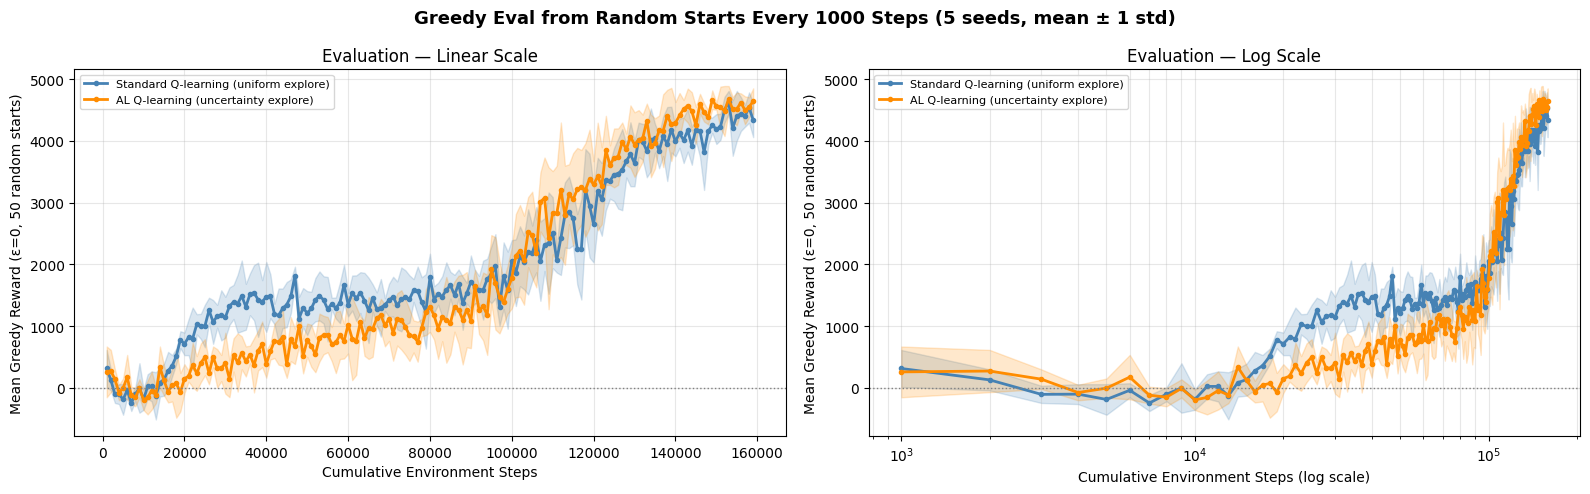

Final greedy evaluation reward (last checkpoint, mean ± std across seeds):
  Standard:     4336.4 ± 277.7
  AL (uncert.): 4641.6 ± 206.5

→ AL/Uncertainty achieves higher final greedy reward by 305.2 points.


In [10]:
# Trim each seed to the min available checkpoint length before stacking
min_ckpts = min(
    min(len(ev) for ev in a_std_eval),
    min(len(ev) for ev in a_al_eval),
)
eval_steps   = [step for step, _ in a_std_eval[0]][:min_ckpts]
eval_mat_std = np.array([[r for _, r in ev[:min_ckpts]] for ev in a_std_eval])
eval_mat_al  = np.array([[r for _, r in ev[:min_ckpts]] for ev in a_al_eval])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, xscale, xlabel in [
    (axes[0], 'linear', 'Cumulative Environment Steps'),
    (axes[1], 'log',    'Cumulative Environment Steps (log scale)'),
]:
    for mat, color, label in [
        (eval_mat_std, 'steelblue',  'Standard Q-learning (uniform explore)'),
        (eval_mat_al,  'darkorange', 'AL Q-learning (uncertainty explore)'),
    ]:
        mean = mat.mean(axis=0)
        std  = mat.std(axis=0)
        ax.plot(eval_steps, mean, color=color, linewidth=2, label=label, marker='o', markersize=3)
        ax.fill_between(eval_steps, mean - std, mean + std, alpha=0.2, color=color)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xscale(xscale)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean Greedy Reward (ε=0, 50 random starts)')
    ax.set_title(f'Evaluation — {xscale.capitalize()} Scale')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle(
    f'Greedy Eval from Random Starts Every {EVAL_STEP_INTERVAL} Steps'
    f' ({N_SEEDS_B} seeds, mean ± 1 std)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Final greedy evaluation reward (last checkpoint, mean ± std across seeds):')
print(f'  Standard:     {eval_mat_std[:, -1].mean():.1f} ± {eval_mat_std[:, -1].std():.1f}')
print(f'  AL (uncert.): {eval_mat_al[:, -1].mean():.1f} ± {eval_mat_al[:, -1].std():.1f}')
winner = 'AL/Uncertainty' if eval_mat_al[:, -1].mean() > eval_mat_std[:, -1].mean() else 'Standard'
delta  = abs(eval_mat_al[:, -1].mean() - eval_mat_std[:, -1].mean())
print(f'\n→ {winner} achieves higher final greedy reward by {delta:.1f} points.')